# Hand patch vs API patch amplification test

这个 notebook 不重写主 pipeline，只复用当前项目模块，专门回答：

> `patch-6` 下，hand patch 和 API patch 的差异，究竟是从哪个环节开始被剧烈放大的？

按阶段比较：

1. patch geometry / metadata  
2. Q catalog / q-index tables  
3. bare vertex 采样  
4. bare diagnosis kernels  
5. initial one-loop RHS  
6. 同样第一步更新之后的 diagnosis


In [2]:

import sys
from pathlib import Path
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from patching import FSPatcher, plot_patchset, PatchPoint, PatchSet
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction, FRGFlowSolver


## 1. Global parameters

In [3]:

MODEL_PARAMS = dict(t=1.0, phi=0.0)
MU = 0.0
NPATCH = 6
GRID_SIZE = 220
CONTOUR_MIN_POINTS = 40

UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1

U_BENCH = 6.0
V_BENCH = 0.0

FLOW_KWARGS = dict(
    T_start=3.0,
    T_stop=0.2,
    n_steps=300,
    nfreq=10,
    diagnose_every=10,
    temperature_grid="log",
    include_explicit_T_prefactor=True,
    max_relative_update=1.0,
    min_substep_fraction=0.1,
    channel_divergence_threshold=1e5,
    eigenvalue_threshold=1e5,
    diagnosis_sort_by="abs",
    track_crossed_channel=True,
    diagnosis_Qs=[
        np.array([0.0, 0.0]),
        np.array([0.0,  np.pi/np.sqrt(3)]),
        np.array([ np.pi/2,  np.pi/(2*np.sqrt(3))]),
        np.array([-np.pi/2,  np.pi/(2*np.sqrt(3))]),
    ],
)

PROBE_DT = -0.02


## 2. Build the two patchsets

In [3]:

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

def build_api_patchsets(model, mu=0.0, npatch=6, grid_size=220, contour_min_points=40):
    patch_up = FSPatcher(
        model,
        band_index=LOCAL_BAND_INDEX,
        mu=mu,
        Npatch=npatch,
        grid_size=grid_size,
        orbital_slice=UP_SLICE,
        contour_min_points=contour_min_points,
        gauge_fix="parallel_transport",
        verbose=False,
    ).build()

    patch_dn = FSPatcher(
        model,
        band_index=LOCAL_BAND_INDEX,
        mu=mu,
        Npatch=npatch,
        grid_size=grid_size,
        orbital_slice=DN_SLICE,
        contour_min_points=contour_min_points,
        gauge_fix="parallel_transport",
        verbose=False,
    ).build()

    return {"up": patch_up, "dn": patch_dn}

def _sector_eig(model, k_cart, orbital_slice, band_index):
    kx, ky = float(k_cart[0]), float(k_cart[1])
    H = np.asarray(model.Hk(kx, ky), dtype=complex)
    Hs = H[orbital_slice, orbital_slice]
    evals, evecs = np.linalg.eigh(Hs)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    u = u / np.linalg.norm(u)
    return float(evals[band_index]), u

def _orbital_weight(u):
    w = np.abs(np.asarray(u, dtype=complex))**2
    return w / np.sum(w)

def _cart_to_red(model, k):
    B = np.column_stack([np.asarray(model.b1, dtype=float),
                         np.asarray(model.b2, dtype=float)])
    return np.linalg.solve(B, np.asarray(k, dtype=float))

def _finite_diff_velocity(model, k_cart, orbital_slice, band_index, h=1e-6):
    kx, ky = float(k_cart[0]), float(k_cart[1])

    def band_energy(x, y):
        H = np.asarray(model.Hk(x, y), dtype=complex)
        Hs = H[orbital_slice, orbital_slice]
        evals, _ = np.linalg.eigh(Hs)
        return float(evals[band_index])

    vx = (band_energy(kx + h, ky) - band_energy(kx - h, ky)) / (2*h)
    vy = (band_energy(kx, ky + h) - band_energy(kx, ky - h)) / (2*h)
    return np.array([vx, vy], dtype=float)

def exact_M6_points(model):
    b1 = np.asarray(model.b1, dtype=float)
    b2 = np.asarray(model.b2, dtype=float)
    M1 = 0.5 * b1
    M2 = 0.5 * b2
    M3 = 0.5 * (b1 + b2)

    ks = np.array([-M1, -M3, -M2, M1, M3, M2], dtype=float)
    ang = np.arctan2(ks[:, 1], ks[:, 0])
    return ks[np.argsort(ang)]

def build_exactM_patchset(model, orbital_slice, band_index):
    M6 = exact_M6_points(model)
    patches = []
    for pid, k in enumerate(M6):
        e, u = _sector_eig(model, k, orbital_slice, band_index)
        vF = _finite_diff_velocity(model, k, orbital_slice, band_index)
        patches.append(
            PatchPoint(
                patch_id=pid,
                k_cart=np.asarray(k, dtype=float),
                k_red=_cart_to_red(model, k),
                energy=e,
                vF=vF,
                vF_norm=float(np.linalg.norm(vF)),
                eigvec=u,
                orbital_weight=_orbital_weight(u),
            )
        )
    return PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,
        band_index=int(band_index),
        filling=np.nan,
        patches=patches,
        fs_contour_k=np.asarray(M6, dtype=float),
        bz_vertices=np.asarray(M6, dtype=float),
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
        gauge_method="manual_exact_M",
        gauge_loop_phase=0.0,
    )

def build_hand_patchsets(model):
    return {
        "up": build_exactM_patchset(model, UP_SLICE, LOCAL_BAND_INDEX),
        "dn": build_exactM_patchset(model, DN_SLICE, LOCAL_BAND_INDEX),
    }

patchsets_api = build_api_patchsets(
    model, mu=MU, npatch=NPATCH, grid_size=GRID_SIZE, contour_min_points=CONTOUR_MIN_POINTS
)
patchsets_hand = build_hand_patchsets(model)

print("API patch counts :", {k: v.Npatch for k, v in patchsets_api.items()})
print("Hand patch counts:", {k: v.Npatch for k, v in patchsets_hand.items()})


API patch counts : {'up': 6, 'dn': 6}
Hand patch counts: {'up': 6, 'dn': 6}


## 3. Quick geometry comparison

In [4]:

def patchset_to_df(patchsets, label):
    rows = []
    for spin in ["up", "dn"]:
        ps = patchsets[spin]
        for p in ps.patches:
            rows.append({
                "patchset": label,
                "spin": spin,
                "patch_id": p.patch_id,
                "kx": float(p.k_cart[0]),
                "ky": float(p.k_cart[1]),
                "E": float(p.energy),
                "vF_norm": float(p.vF_norm),
                "wA": float(p.orbital_weight[0]),
                "wB": float(p.orbital_weight[1]),
                "wC": float(p.orbital_weight[2]),
                "gauge_method": getattr(ps, "gauge_method", None),
                "mu_used_for_contour": float(getattr(ps, "mu_used_for_contour", np.nan)),
            })
    return pd.DataFrame(rows)

df_patch = pd.concat([
    patchset_to_df(patchsets_hand, "hand"),
    patchset_to_df(patchsets_api, "api"),
], ignore_index=True)

display(df_patch.sort_values(["spin", "patchset", "patch_id"]).reset_index(drop=True))


,patchset,spin,patch_id,kx,ky,E,vF_norm,wA,wB,wC,gauge_method,mu_used_for_contour
0,api,dn,0,-0.017789,1.803529,4.362710e-18,7.113915e-02,9.996836e-01,3.780250e-33,3.163988e-04,parallel_transport,0.0005
1,api,dn,1,-1.570796,0.886159,4.398395e-18,7.183124e-02,3.744563e-33,3.225871e-04,9.996774e-01,parallel_transport,0.0005
2,api,dn,2,-1.552876,-0.917246,-3.469447e-18,7.166576e-02,3.211020e-04,9.996789e-01,1.271089e-39,parallel_transport,0.0005
3,api,dn,3,0.016434,-1.804311,4.025362e-18,6.572224e-02,9.997300e-01,3.754969e-33,2.700363e-04,parallel_transport,0.0005
4,api,dn,4,1.570796,-0.887797,4.051198e-18,6.616109e-02,3.745296e-33,2.736555e-04,9.997263e-01,parallel_transport,0.0005
5,api,dn,5,1.554368,0.916385,3.469447e-18,6.570180e-02,2.698683e-04,9.997301e-01,4.927720e-32,parallel_transport,0.0005
6,hand,dn,0,-1.570796,-0.906900,1.094764e-47,3.682756e-16,3.749399e-33,1.000000e+00,0.000000e+00,manual_exact_M,0.0000
7,hand,dn,1,-1.570796,-2.720699,-1.499760e-32,2.449302e-16,3.749399e-33,3.749399e-33,1.000000e+00,manual_exact_M,0.0000
8,hand,dn,2,-0.000000,-1.813799,1.499760e-32,1.193415e-15,1.000000e+00,3.749399e-33,3.749399e-33,manual_exact_M,0.0000
9,hand,dn,3,1.570796,0.906900,1.094764e-47,3.682756e-16,3.749399e-33,1.000000e+00,0.000000e+00,manual_exact_M,0.0000


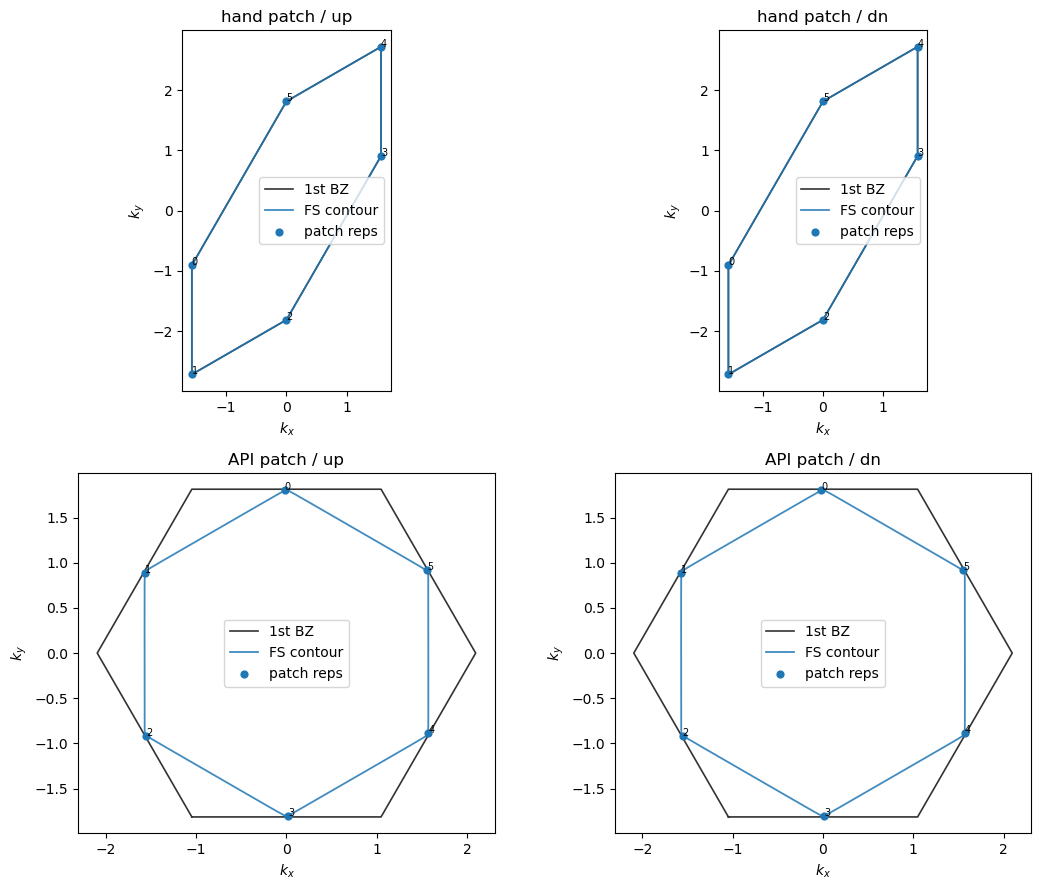

In [5]:

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

plot_patchset(patchsets_hand["up"], ax=axes[0, 0], show_contour=True, show_velocity=False, show_bz=True)
axes[0, 0].set_title("hand patch / up")

plot_patchset(patchsets_hand["dn"], ax=axes[0, 1], show_contour=True, show_velocity=False, show_bz=True)
axes[0, 1].set_title("hand patch / dn")

plot_patchset(patchsets_api["up"], ax=axes[1, 0], show_contour=True, show_velocity=False, show_bz=True)
axes[1, 0].set_title("API patch / up")

plot_patchset(patchsets_api["dn"], ax=axes[1, 1], show_contour=True, show_velocity=False, show_bz=True)
axes[1, 1].set_title("API patch / dn")

plt.tight_layout()
plt.show()


## 4. Shared helpers

In [6]:

def build_solver(model, patchsets, U, V, flow_kwargs=None):
    flow_kwargs = {} if flow_kwargs is None else dict(flow_kwargs)
    interaction = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(interaction, patchsets)
    solver = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma,
        **flow_kwargs,
    )
    return interaction, bare_gamma, solver

def q_list_df(solver, patch_label):
    rows = []
    for grid_name, grid in [("pp", solver.pp_grid), ("phd", solver.phd_grid), ("phc", solver.phc_grid)]:
        for iq, q in enumerate(grid.q_list):
            rows.append({"patchset": patch_label, "grid": grid_name, "iq": iq, "qx": float(q[0]), "qy": float(q[1])})
    return pd.DataFrame(rows)

def summarize_q_index_table(arr, name, patch_label):
    arr = np.asarray(arr, dtype=int)
    vals, counts = np.unique(arr, return_counts=True)
    rows = []
    for v, c in zip(vals, counts):
        rows.append({"patchset": patch_label, "table": name, "iq": int(v), "count": int(c)})
    return pd.DataFrame(rows)

def compare_patch_position_distance(patchsets_a, patchsets_b):
    rows = []
    for spin in ["up", "dn"]:
        ks_a = np.asarray([p.k_cart for p in patchsets_a[spin].patches], dtype=float)
        ks_b = np.asarray([p.k_cart for p in patchsets_b[spin].patches], dtype=float)
        for i in range(min(len(ks_a), len(ks_b))):
            rows.append({"spin": spin, "patch_id": i, "delta_k_norm": float(np.linalg.norm(ks_a[i] - ks_b[i]))})
    return pd.DataFrame(rows)

def bare_vertex_stats(bare_gamma, spin_blocks, Npatch):
    rows = []
    for blk in spin_blocks:
        s1, s2, s3, s4 = blk
        vals = []
        for p1 in range(Npatch):
            for p2 in range(Npatch):
                for p3 in range(Npatch):
                    for p4 in range(Npatch):
                        vals.append(abs(bare_gamma(p1, s1, p2, s2, p3, s3, p4, s4)))
        vals = np.asarray(vals, dtype=float)
        rows.append({"spin_block": str(blk), "max_abs": float(np.max(vals)), "mean_abs": float(np.mean(vals)), "std_abs": float(np.std(vals))})
    return pd.DataFrame(rows)

def kernel_summary_dict(kdict, patch_label, stage, Q_label):
    rows = []
    for name, ker in kdict.items():
        vals, _vecs = ker.eig(sort_by="abs")
        lead = vals[0] if len(vals) else 0.0
        rows.append({
            "patchset": patch_label,
            "stage": stage,
            "Q_label": Q_label,
            "kernel": name,
            "lead_abs_eval": float(abs(lead)),
            "lead_real_eval": float(np.real(lead)),
            "matrix_norm_maxabs": float(np.max(np.abs(ker.matrix))),
            "herm_resid": float(ker.hermitian_residual()),
        })
    return pd.DataFrame(rows)

def rhs_store_summary(rhs_store, patch_label, channel_name):
    rows = []
    for key, mat in rhs_store.items():
        s1, s2, s3, s4, iq = key
        rows.append({
            "patchset": patch_label,
            "channel": channel_name,
            "spin_block": str((s1, s2, s3, s4)),
            "iq": int(iq),
            "max_abs": float(np.max(np.abs(mat))),
            "fro_norm": float(np.linalg.norm(mat)),
        })
    return pd.DataFrame(rows)

def record_summary(rec, patch_label):
    return {
        "patchset": patch_label,
        "step": int(rec.step_index),
        "T": float(rec.temperature),
        "rhs_norm": float(rec.rhs_norm),
        "channel_norm": float(rec.channel_norm),
        "accepted_substeps": int(rec.accepted_substeps),
        "max_rel_update": float(rec.max_rel_update),
        "leading_channel_name": rec.leading_channel_name,
        "leading_order_label": rec.leading_order_label,
        "leading_eigenvalue_abs": None if rec.leading_eigenvalue_abs is None else float(rec.leading_eigenvalue_abs),
        "instability": bool(rec.instability),
        "instability_reason": rec.instability_reason,
        "termination_reason": rec.termination_reason,
    }


## 5. Build the two solvers at the same benchmark point

In [7]:

interaction_hand, bare_gamma_hand, solver_hand = build_solver(
    model=model, patchsets=patchsets_hand, U=U_BENCH, V=V_BENCH, flow_kwargs=FLOW_KWARGS
)
interaction_api, bare_gamma_api, solver_api = build_solver(
    model=model, patchsets=patchsets_api, U=U_BENCH, V=V_BENCH, flow_kwargs=FLOW_KWARGS
)

print("hand spin blocks:", solver_hand.spin_blocks)
print("api  spin blocks:", solver_api.spin_blocks)


hand spin blocks: [('up', 'up', 'up', 'up'), ('dn', 'dn', 'dn', 'dn'), ('up', 'dn', 'up', 'dn'), ('up', 'dn', 'dn', 'up'), ('dn', 'up', 'up', 'dn'), ('dn', 'up', 'dn', 'up')]
api  spin blocks: [('up', 'up', 'up', 'up'), ('dn', 'dn', 'dn', 'dn'), ('up', 'dn', 'up', 'dn'), ('up', 'dn', 'dn', 'up'), ('dn', 'up', 'up', 'dn'), ('dn', 'up', 'dn', 'up')]


## 6. Stage A — patch geometry

In [8]:
display(compare_patch_position_distance(patchsets_hand, patchsets_api))

,spin,patch_id,delta_k_norm
0,up,0,3.123821
1,up,1,3.606858
2,up,2,1.793107
3,up,3,3.125174
4,up,4,3.608496
5,up,5,1.794829
6,dn,0,3.123821
7,dn,1,3.606858
8,dn,2,1.793107
9,dn,3,3.125174


## 7. Stage B — Q catalogs and q-index tables

In [9]:

df_q = pd.concat([q_list_df(solver_hand, "hand"), q_list_df(solver_api, "api")], ignore_index=True)
display(df_q.sort_values(["grid", "patchset", "iq"]).reset_index(drop=True))


,patchset,grid,iq,qx,qy
0,api,phc,0,0.000000,0.000000
1,api,phc,1,1.588585,4.524028
2,api,phc,2,1.606505,2.720623
3,api,phc,3,0.017920,1.824193
4,hand,phc,0,0.000000,0.000000
5,hand,phc,1,0.000000,1.813799
6,hand,phc,2,1.570796,2.720699
7,hand,phc,3,1.570796,0.906900
8,api,phd,0,0.000000,0.000000
9,api,phd,1,1.588585,4.524028


In [10]:

df_qtables = pd.concat([
    summarize_q_index_table(solver_hand._pp_q_index[("up", "up")], "pp_q_index[(up,up)]", "hand"),
    summarize_q_index_table(solver_api._pp_q_index[("up", "up")], "pp_q_index[(up,up)]", "api"),
    summarize_q_index_table(solver_hand._phd_q_index[("up", "up")], "phd_q_index[(up,up)]", "hand"),
    summarize_q_index_table(solver_api._phd_q_index[("up", "up")], "phd_q_index[(up,up)]", "api"),
    summarize_q_index_table(solver_hand._phc_q_index[("up", "up")], "phc_q_index[(up,up)]", "hand"),
    summarize_q_index_table(solver_api._phc_q_index[("up", "up")], "phc_q_index[(up,up)]", "api"),
], ignore_index=True)
display(df_qtables.sort_values(["table", "patchset", "iq"]).reset_index(drop=True))


,patchset,table,iq,count
0,api,"phc_q_index[(up,up)]",0,12
1,api,"phc_q_index[(up,up)]",1,8
2,api,"phc_q_index[(up,up)]",2,8
3,api,"phc_q_index[(up,up)]",3,8
4,hand,"phc_q_index[(up,up)]",0,12
5,hand,"phc_q_index[(up,up)]",1,8
6,hand,"phc_q_index[(up,up)]",2,8
7,hand,"phc_q_index[(up,up)]",3,8
8,api,"phd_q_index[(up,up)]",0,12
9,api,"phd_q_index[(up,up)]",1,8


## 8. Stage C — bare vertex statistics

In [11]:

df_bare_stats = pd.concat([
    bare_vertex_stats(bare_gamma_hand, solver_hand.spin_blocks, patchsets_hand["up"].Npatch).assign(patchset="hand"),
    bare_vertex_stats(bare_gamma_api, solver_api.spin_blocks, patchsets_api["up"].Npatch).assign(patchset="api"),
], ignore_index=True)
display(df_bare_stats[["patchset", "spin_block", "max_abs", "mean_abs", "std_abs"]].sort_values(["spin_block", "patchset"]).reset_index(drop=True))


,patchset,spin_block,max_abs,mean_abs,std_abs
0,api,"('dn', 'dn', 'dn', 'dn')",0.000000,0.000000,0.000000
1,hand,"('dn', 'dn', 'dn', 'dn')",0.000000,0.000000,0.000000
2,api,"('dn', 'up', 'dn', 'up')",5.996762,0.237752,1.129959
3,hand,"('dn', 'up', 'dn', 'up')",6.000000,0.222222,1.133115
4,api,"('dn', 'up', 'up', 'dn')",5.996762,0.237752,1.129959
5,hand,"('dn', 'up', 'up', 'dn')",6.000000,0.222222,1.133115
6,api,"('up', 'dn', 'dn', 'up')",5.996762,0.237752,1.129959
7,hand,"('up', 'dn', 'dn', 'up')",6.000000,0.222222,1.133115
8,api,"('up', 'dn', 'up', 'dn')",5.996762,0.237752,1.129959
9,hand,"('up', 'dn', 'up', 'dn')",6.000000,0.222222,1.133115


## 9. Stage D — bare diagnosis kernels

In [12]:

Q_probe_list = FLOW_KWARGS["diagnosis_Qs"]

rows = []
for iQ, Q in enumerate(Q_probe_list):
    rows.append(kernel_summary_dict(solver_hand.build_diagnosis_kernel_dict(Q), "hand", "bare", f"Q{iQ}"))
    rows.append(kernel_summary_dict(solver_api.build_diagnosis_kernel_dict(Q),  "api",  "bare", f"Q{iQ}"))

df_kernel_bare = pd.concat(rows, ignore_index=True)
display(df_kernel_bare.sort_values(["Q_label", "kernel", "patchset"]).reset_index(drop=True))


,patchset,stage,Q_label,kernel,lead_abs_eval,lead_real_eval,matrix_norm_maxabs,herm_resid
0,api,bare,Q0,ph_charge_longitudinal,1.200000e+01,-1.200000e+01,5.996762e+00,8.881784e-16
1,hand,bare,Q0,ph_charge_longitudinal,1.200000e+01,-1.200000e+01,6.000000e+00,0.000000e+00
2,api,bare,Q0,ph_spin_longitudinal,1.200000e+01,1.200000e+01,5.996762e+00,8.881784e-16
3,hand,bare,Q0,ph_spin_longitudinal,1.200000e+01,1.200000e+01,6.000000e+00,0.000000e+00
4,api,bare,Q0,phc_dd,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...
139,hand,bare,Q3,pp_triplet_uu,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
140,api,bare,Q3,pp_ud_to_du,7.089549e-03,-7.089549e-03,1.926002e-03,4.336809e-19
141,hand,bare,Q3,pp_ud_to_du,1.799712e-31,-1.799712e-31,4.499279e-32,0.000000e+00
142,api,bare,Q3,pp_ud_to_ud,7.089549e-03,7.089549e-03,1.926002e-03,4.336809e-19


## 10. Stage E — initial one-loop RHS at the same starting temperature

In [13]:

rhs_pp_hand, rhs_phd_hand, rhs_phc_hand = solver_hand.compute_channel_rhs(FLOW_KWARGS["T_start"])
rhs_pp_api,  rhs_phd_api,  rhs_phc_api  = solver_api.compute_channel_rhs(FLOW_KWARGS["T_start"])

df_rhs = pd.concat([
    rhs_store_summary(rhs_pp_hand,  "hand", "rhs_pp"),
    rhs_store_summary(rhs_phd_hand, "hand", "rhs_phd"),
    rhs_store_summary(rhs_phc_hand, "hand", "rhs_phc"),
    rhs_store_summary(rhs_pp_api,   "api",  "rhs_pp"),
    rhs_store_summary(rhs_phd_api,  "api",  "rhs_phd"),
    rhs_store_summary(rhs_phc_api,  "api",  "rhs_phc"),
], ignore_index=True)

display(
    df_rhs.groupby(["patchset", "channel", "iq"], as_index=False)[["max_abs", "fro_norm"]]
          .max()
          .sort_values(["channel", "iq", "patchset"])
          .reset_index(drop=True)
)


,patchset,channel,iq,max_abs,fro_norm
0,api,rhs_phc,0,3.918271e+00,1.357253e+01
1,hand,rhs_phc,0,3.922686e+00,1.358858e+01
2,api,rhs_phc,1,7.274007e-07,2.696425e-06
3,hand,rhs_phc,1,1.102902e-64,4.411609e-64
4,api,rhs_phc,2,7.761954e-07,2.854402e-06
5,hand,rhs_phc,2,4.411609e-64,1.764644e-63
6,api,rhs_phc,3,7.231025e-07,2.670807e-06
7,hand,rhs_phc,3,4.411609e-64,1.764644e-63
8,api,rhs_phd,0,3.918271e+00,1.357253e+01
9,hand,rhs_phd,0,3.922686e+00,1.358858e+01


## 11. Stage F — take the same first probe step, then compare diagnosis again

In [14]:

_, _, solver_hand_probe = build_solver(model, patchsets_hand, U_BENCH, V_BENCH, FLOW_KWARGS)
_, _, solver_api_probe  = build_solver(model, patchsets_api,  U_BENCH, V_BENCH, FLOW_KWARGS)

rec_hand = solver_hand_probe.step(FLOW_KWARGS["T_start"], PROBE_DT)
rec_api  = solver_api_probe.step(FLOW_KWARGS["T_start"], PROBE_DT)

display(pd.DataFrame([record_summary(rec_hand, "hand"), record_summary(rec_api, "api")]))


,patchset,step,T,rhs_norm,channel_norm,accepted_substeps,max_rel_update,leading_channel_name,leading_order_label,leading_eigenvalue_abs,instability,instability_reason,termination_reason
0,hand,0,2.98,3.922686,0.078454,1,0.013076,None,None,None,False,None,None
1,api,0,2.98,3.918271,0.078365,1,0.013068,None,None,None,False,None,None


In [15]:

rows = []
for iQ, Q in enumerate(Q_probe_list):
    rows.append(kernel_summary_dict(solver_hand_probe.build_diagnosis_kernel_dict(Q), "hand", "after_one_probe_step", f"Q{iQ}"))
    rows.append(kernel_summary_dict(solver_api_probe.build_diagnosis_kernel_dict(Q),  "api",  "after_one_probe_step", f"Q{iQ}"))

df_kernel_after = pd.concat(rows, ignore_index=True)
display(df_kernel_after.sort_values(["Q_label", "kernel", "patchset"]).reset_index(drop=True))


,patchset,stage,Q_label,kernel,lead_abs_eval,lead_real_eval,matrix_norm_maxabs,herm_resid
0,api,after_one_probe_step,Q0,ph_charge_longitudinal,1.199963e+01,-1.199963e+01,5.996758e+00,2.909567e-08
1,hand,after_one_probe_step,Q0,ph_charge_longitudinal,1.200000e+01,-1.200000e+01,6.000000e+00,4.456900e-38
2,api,after_one_probe_step,Q0,ph_spin_longitudinal,1.200000e+01,1.200000e+01,5.996758e+00,2.909567e-08
3,hand,after_one_probe_step,Q0,ph_spin_longitudinal,1.200000e+01,1.200000e+01,6.000000e+00,4.456900e-38
4,api,after_one_probe_step,Q0,phc_dd,1.853414e-04,-1.853414e-04,4.864817e-05,8.027078e-06
...,...,...,...,...,...,...,...,...
139,hand,after_one_probe_step,Q3,pp_triplet_uu,4.706470e-33,4.706470e-33,1.176617e-33,3.342140e-70
140,api,after_one_probe_step,Q3,pp_ud_to_du,6.996905e-03,-6.996905e-03,1.926002e-03,4.015817e-06
141,hand,after_one_probe_step,Q3,pp_ud_to_du,1.776179e-31,-1.776179e-31,4.499279e-32,3.342140e-70
142,api,after_one_probe_step,Q3,pp_ud_to_ud,6.996877e-03,6.996877e-03,1.926003e-03,4.013689e-06


## 12. Compact amplification summary

In [16]:

def top_kernel_table(df):
    out = (
        df.sort_values(["Q_label", "patchset", "lead_abs_eval"], ascending=[True, True, False])
          .groupby(["stage", "Q_label", "patchset"], as_index=False)
          .head(1)
          .copy()
    )
    return out[["stage", "Q_label", "patchset", "kernel", "lead_abs_eval", "lead_real_eval", "matrix_norm_maxabs"]]

display(pd.concat([top_kernel_table(df_kernel_bare), top_kernel_table(df_kernel_after)], ignore_index=True)
          .sort_values(["stage", "Q_label", "patchset"])
          .reset_index(drop=True))


,stage,Q_label,patchset,kernel,lead_abs_eval,lead_real_eval,matrix_norm_maxabs
0,after_one_probe_step,Q0,api,pp_singlet_sz0,2.400032e+01,2.400032e+01,1.199297e+01
1,after_one_probe_step,Q0,hand,pp_singlet_sz0,2.400000e+01,2.400000e+01,1.200000e+01
2,after_one_probe_step,Q1,api,pp_singlet_sz0,1.411865e-02,1.411865e-02,3.821385e-03
3,after_one_probe_step,Q1,hand,pp_singlet_sz0,1.776179e-31,1.776179e-31,4.440448e-32
4,after_one_probe_step,Q2,api,pp_singlet_sz0,1.388637e-02,1.388637e-02,3.748000e-03
5,after_one_probe_step,Q2,hand,pp_singlet_sz0,3.552359e-31,3.552359e-31,8.880897e-32
6,after_one_probe_step,Q3,api,pp_singlet_sz0,1.399378e-02,1.399378e-02,3.803685e-03
7,after_one_probe_step,Q3,hand,pp_singlet_sz0,3.552359e-31,3.552359e-31,8.880897e-32
8,bare,Q0,api,pp_singlet_sz0,2.399995e+01,2.399995e+01,1.199296e+01
9,bare,Q0,hand,pp_singlet_sz0,2.400000e+01,2.400000e+01,1.200000e+01


## 13. How to read the output

按下面顺序看：

### (A) 如果几何层就已经差很大
- patch 位置
- 局域轨道权重
- \(v_F\)

那说明差异很早就被注入了。

### (B) 如果几何层差别不大，但 Q catalog / q-index table 已经明显不同
重点就转到：
- patch 生成的 transfer sectors
- partner mapping / q-index bookkeeping

### (C) 如果 bare diagnosis kernel 还很像，但 initial RHS 已经强烈分叉
那主要放大发生在：
- one-loop bubble
- channel RHS 这一层

### (D) 如果 initial RHS 还像，但同样第一步更新之后 diagnosis 就明显分叉
那主要放大来自：
- flow update
- adaptive / nonlinear feedback

跑完这个 notebook 后，你基本就能把问题缩到：
1. patch geometry
2. Q / q-index / partner mapping
3. one-loop RHS
4. 第一步更新反馈
这四类之一。
